<a href="https://colab.research.google.com/github/sumeetborkar03-alt/gold-price/blob/development/data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path

In [2]:

try:
    # Works in .py script
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Works in Jupyter Notebook
    BASE_DIR = Path().resolve().parents[1]

DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)

Base directory: E:\gold_price\gold-price
Data directory: E:\gold_price\gold-price\data


In [3]:
def download_etf_data(ticker_symbol: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    """
    Downloads historical ETF data for a given ticker symbol.

    Args:
        ticker_symbol (str): The ticker symbol of the ETF.
        period (str): The period over which to download data (e.g., "5y", "1y", "3mo").
        interval (str): The interval of the data (e.g., "1d", "1wk", "1mo").

    Returns: 
        pd.DataFrame: A DataFrame containing the historical ETF data.
    """
    print(f"Downloading data for {ticker_symbol}...")
    df = yf.download(ticker_symbol, period=period, interval=interval, auto_adjust=False)
    df = df.reset_index()
    return df

def save_dataframe_to_csv(df: pd.DataFrame, DATA_DIR: str, filename: str, subfolder="dev"):
    """
    Saves a pandas DataFrame to a CSV file.

    Args:
        df (pd.DataFrame): The DataFrame to save.
        filename (str): The name of the CSV file.
    """
    save_dir = DATA_DIR / subfolder
    save_dir.mkdir(parents=True, exist_ok=True)

    file_path = save_dir / filename
    df.to_csv(file_path, index=False)
    print(f"Data saved successfully to: {file_path}")
    return

In [4]:
ticker = "HDFCGOLD.NS"
file_name = "hdfc_gold_5_year_etf.csv"
hdfc_gold_5_year_etf = download_etf_data(ticker_symbol=ticker, period="5y", interval="1d")
save_dataframe_to_csv(df=hdfc_gold_5_year_etf, DATA_DIR=DATA_DIR, filename=file_name)

[*********************100%***********************]  1 of 1 completed

Data saved successfully to: E:\gold_price\gold-price\data\dev\hdfc_gold_5_year_etf.csv


In [5]:
def get_scheme_code_list (scheme_name: str) -> pd.DataFrame:

  res = requests.get("https://api.mfapi.in/mf")
  data = res.json()
  mf_df = pd.DataFrame(data)

  df_scheme = mf_df[mf_df["schemeName"].str.contains(scheme_name, case=False, na=False)]
  return df_scheme


df_scheme = get_scheme_code_list(scheme_name='hdfc gold')
display(df_scheme)

,schemeCode,schemeName,isinGrowth,isinDivReinvestment
9414,113049,HDFC Gold ETF - Growth Option,INF179KC1981,None
11384,115934,HDFC Gold ETF Fund of Fund - Growth Option,INF179K01LC5,None
14106,119132,HDFC Gold ETF Fund of Fund - Direct Plan,INF179K01VX0,None


In [10]:
def get_nav(scheme_code: str, DATA_DIR: str, subfolder="dev") -> pd.DataFrame:

  res = requests.get(f"https://api.mfapi.in/mf/{scheme_code}")
  data = res.json()
  df_nav = pd.DataFrame(data['data'])

  save_dir = DATA_DIR / subfolder
  save_dir.mkdir(parents=True, exist_ok=True)

  filename = f"{scheme_code}.csv"

  file_path = save_dir / filename
  print(save_dir)
  
  df_nav.to_csv(file_path, index=False)
  return df_nav


df_nav = get_nav(scheme_code='119132', DATA_DIR=DATA_DIR)

E:\gold_price\gold-price\data\dev


C:\Users\Sumeet\AppData\Local\Temp\ipykernel_3228\879318082.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_nav['Date'] = pd.to_datetime(df_nav['Date'])


,Date,Close,nav
0,2023-06-08,52.230000,19.1749
1,2023-06-09,52.529999,19.2848
2,2023-06-12,52.549999,19.2919
3,2023-06-13,52.500000,19.2735
4,2023-06-14,51.919998,19.0607


Correlation between Close and NAV: 0.999999704075781


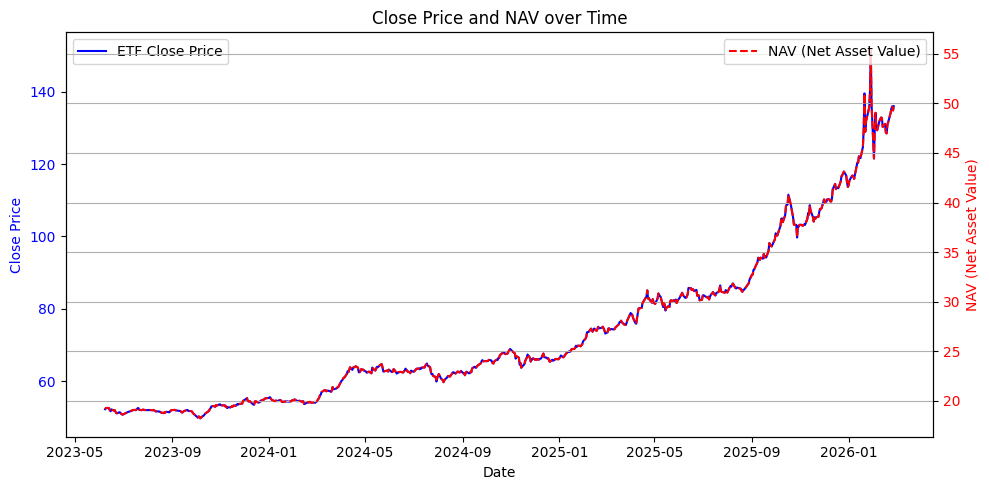

In [12]:
def compare_mf_nav_with(mf_csv, nav_csv, DATA_DIR: str, subfolder="dev") -> pd.DataFrame:
  df_mf = pd.read_csv(DATA_DIR/ subfolder/ mf_csv)
  df_nav = pd.read_csv(DATA_DIR/ subfolder/ nav_csv)

  df_nav = df_nav.rename(columns={'date': 'Date'})
  df_nav['Date'] = pd.to_datetime(df_nav['Date'])

  df_mf = df_mf.drop(columns=['Open', 'High', 'Low', 'Adj Close', 'Volume'])
  df_mf = df_mf.dropna()
  df_mf['Date'] = pd.to_datetime(df_mf['Date'])
  df_mf['Close'] = df_mf['Close'].str.replace(',', '').astype(float)

  combine_df = pd.merge(df_mf, df_nav, on='Date', how='inner')

  combine_df.sort_values(by='Date', ascending=True, inplace=True)
  display(combine_df.head())
  correlation = combine_df['Close'].corr(combine_df['nav'])
  print(f"Correlation between Close and NAV: {correlation}")

  fig, ax1 = plt.subplots(figsize=(10, 5))

  # Plot Close Price on primary y-axis with a solid blue line
  sns.lineplot(data=combine_df, x='Date', y='Close', label='ETF Close Price', color='blue', linestyle='-', ax=ax1)
  ax1.set_xlabel('Date')
  ax1.set_ylabel('Close Price', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax1.legend(loc='upper left')

  # Create a secondary y-axis for NAV with a dashed red line
  ax2 = ax1.twinx()
  sns.lineplot(data=combine_df, x='Date', y='nav', label='NAV (Net Asset Value)', color='red', linestyle='--', ax=ax2)
  ax2.set_ylabel('NAV (Net Asset Value)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax2.legend(loc='upper right')

  plt.title('Close Price and NAV over Time')
  plt.grid(True)
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  return combine_df

combine_df = compare_mf_nav_with(mf_csv='hdfc_gold_5_year_etf.csv', nav_csv='119132.csv', DATA_DIR=DATA_DIR)

This plot visualizes the 'Close Price' and 'NAV' over time, demonstrating their highly similar trends.